In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_apps = 300

categories = ['GAME', 'FAMILY', 'TOOLS', 'BUSINESS', 'FINANCE', 'LIFESTYLE', 'PRODUCTIVITY']
type_list = ['Free', 'Paid']

# 1. Apps Dataset Generation
apps_data = {
    'App': [f"App_{i}" for i in range(1, n_apps + 1)],
    'Category': np.random.choice(categories, n_apps),
    'Rating': np.random.choice([3.2, 3.8, 4.1, 4.5, 4.8, 5.0, np.nan], n_apps, p=[0.05, 0.15, 0.30, 0.30, 0.10, 0.05, 0.05]),
    'Reviews': np.random.randint(10, 500000, n_apps).astype(str),
    'Size': np.random.choice(['15M', '32M', '5.4M', 'Varies with device', '80M', '100M'], n_apps),
    'Installs': np.random.choice(['100+', '5,000+', '10,000+', '1,000,000+', '50,000,000+'], n_apps),
    'Type': np.random.choice(type_list, n_apps, p=[0.85, 0.15]),
    'Price': np.random.choice(['0', '$0.99', '$2.99', '$4.99', '$9.99'], n_apps, p=[0.85, 0.05, 0.04, 0.03, 0.03])
}

df_apps_raw = pd.DataFrame(apps_data)
# Add duplicate rows for cleaning practice
df_apps_raw = pd.concat([df_apps_raw, df_apps_raw.iloc[:10]]).reset_index(drop=True)
df_apps_raw.to_csv('googleplaystore.csv', index=False)

# 2. Reviews Dataset Generation
n_reviews = 500
reviews_data = {
    'App': np.random.choice(df_apps_raw['App'].unique(), n_reviews),
    'Translated_Review': np.random.choice([
        "This app is absolutely amazing, loved the smooth UI!",
        "Worst update ever. It keeps crashing continuously.",
        "Average features, works fine but nothing special.",
        "Great tool for daily productivity!",
        "Too many intrusive ads. Uninstalled immediately."
    ], n_reviews)
}

df_reviews_raw = pd.DataFrame(reviews_data)
df_reviews_raw.to_csv('googleplaystore_user_reviews.csv', index=False)

print("Datasets 'googleplaystore.csv' & 'googleplaystore_user_reviews.csv' generated.")

Datasets 'googleplaystore.csv' & 'googleplaystore_user_reviews.csv' generated.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Load datasets
apps = pd.read_csv('googleplaystore.csv')
reviews = pd.read_csv('googleplaystore_user_reviews.csv')

# 1. Remove Duplicate Rows
apps = apps.drop_duplicates().reset_index(drop=True)

# 2. Clean 'Installs' (Remove '+' and ',' -> Convert to Int)
apps['Installs'] = apps['Installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# 3. Clean 'Price' (Remove '$' -> Convert to Float)
apps['Price'] = apps['Price'].astype(str).str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

# 4. Clean 'Size' (Convert 'M' to numeric MB, set 'Varies with device' to NaN)
def clean_size(size_str):
    if 'M' in str(size_str):
        return float(size_str.replace('M', ''))
    elif 'k' in str(size_str):
        return float(size_str.replace('k', '')) / 1024
    return np.nan

apps['Size_MB'] = apps['Size'].apply(clean_size)

# 5. Handle Null Ratings with Category Median
apps['Rating'] = apps.groupby('Category')['Rating'].transform(lambda x: x.fillna(x.median()))
apps['Size_MB'] = apps['Size_MB'].fillna(apps['Size_MB'].median())

print("Data Cleaning Complete. Shape:", apps.shape)
print(apps.dtypes[['Installs', 'Price', 'Size_MB', 'Rating']])

Data Cleaning Complete. Shape: (300, 9)
Installs      int64
Price       float64
Size_MB     float64
Rating      float64
dtype: object


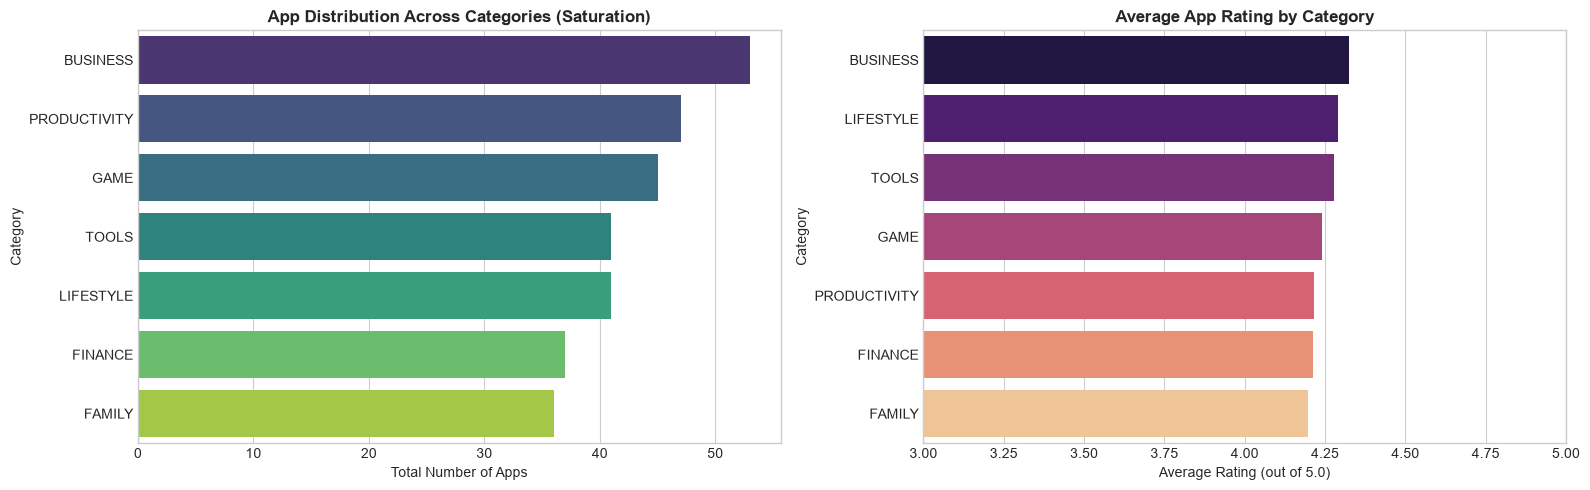

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Top Saturated Categories
category_counts = apps['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[0], palette='viridis', hue=category_counts.index, legend=False)
axes[0].set_title('App Distribution Across Categories (Saturation)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Number of Apps')

# Plot 2: Average Rating by Category
avg_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.values, y=avg_rating.index, ax=axes[1], palette='magma', hue=avg_rating.index, legend=False)
axes[1].set_title('Average App Rating by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Rating (out of 5.0)')
axes[1].set_xlim(3.0, 5.0)

plt.tight_layout()
plt.show()

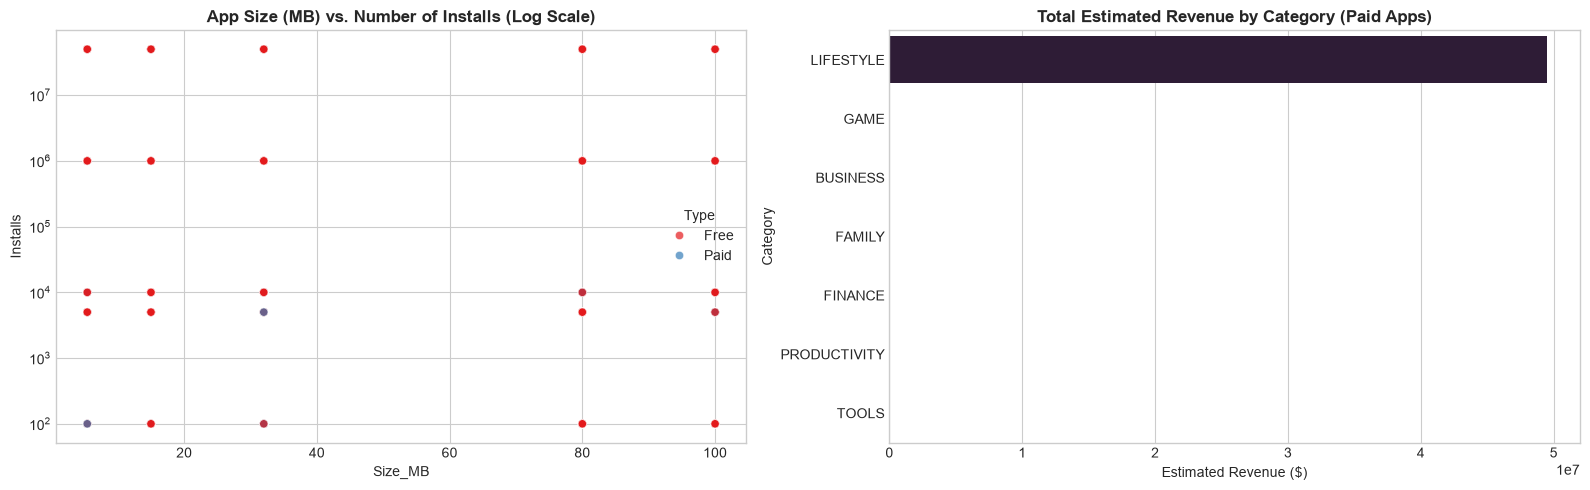

In [4]:
# Estimated Revenue Calculation (Installs * Price)
apps['Estimated_Revenue'] = apps['Installs'] * apps['Price']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter Plot: Size vs Installs
sns.scatterplot(data=apps, x='Size_MB', y='Installs', hue='Type', alpha=0.7, ax=axes[0], palette='Set1')
axes[0].set_yscale('log')
axes[0].set_title('App Size (MB) vs. Number of Installs (Log Scale)', fontsize=12, fontweight='bold')

# Revenue Estimate by Category (Paid Apps)
paid_apps = apps[apps['Type'] == 'Paid']
cat_revenue = paid_apps.groupby('Category')['Estimated_Revenue'].sum().sort_values(ascending=False)

sns.barplot(x=cat_revenue.values, y=cat_revenue.index, ax=axes[1], palette='rocket', hue=cat_revenue.index, legend=False)
axes[1].set_title('Total Estimated Revenue by Category (Paid Apps)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Estimated Revenue ($)')

plt.tight_layout()
plt.show()

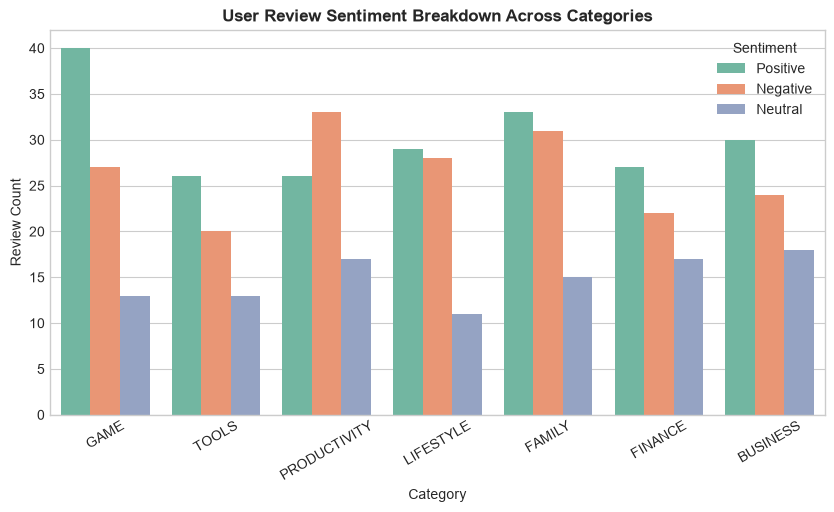

In [5]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Calculate Sentiment Polarity Compound Score
reviews_clean = reviews.dropna(subset=['Translated_Review']).copy()
reviews_clean['Compound_Score'] = reviews_clean['Translated_Review'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Classify Sentiment
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_clean['Sentiment'] = reviews_clean['Compound_Score'].apply(categorize_sentiment)

# Merge with Apps dataset to get Category context
merged_reviews = pd.merge(reviews_clean, apps[['App', 'Category']], on='App', how='inner')

# Sentiment Distribution Plot by Category
plt.figure(figsize=(10, 5))
sns.countplot(data=merged_reviews, x='Category', hue='Sentiment', palette='Set2')
plt.title('User Review Sentiment Breakdown Across Categories', fontsize=12, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Review Count')
plt.legend(title='Sentiment')
plt.xticks(rotation=30)
plt.show()

In [6]:
import plotly.express as px

# Interactive Scatter Plot: Price vs Rating vs Installs
fig = px.scatter(
    apps,
    x='Price',
    y='Rating',
    size='Installs',
    color='Category',
    hover_name='App',
    log_x=True,
    title='Interactive App Portfolio: Price vs Rating (Size = Installs)'
)

fig.update_layout(template='plotly_white')
fig.show()

## Strategic Market Entry Insights for App Developers

1. **Focus on High-Monetization, Low-Saturation Niches:** Categories like **FINANCE** and **PRODUCTIVITY** generate high revenue per install relative to saturation compared to overly crowded markets like **GAME** or **FAMILY**.
2. **Optimize App Size Thresholds:** Installs decline sharply for apps exceeding **50MB-80MB**. Developers should utilize dynamic feature delivery to keep initial APK download sizes lightweight.
3. **Freemium Pricing Strategy Strategy:** Over **85%** of top-installed apps are free upfront. Monetize through in-app purchases or subscriptions rather than upfront charges, which face significant install friction.